In [1]:
!pip install torch torchvision torchaudio scikit-learn pandas numpy matplotlib


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()  # 👈 choose archive.zip from your computer


# === Unzip and load ===
import zipfile
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

# find the CSV inside
import os
for f in os.listdir('/content/data'):
    if f.endswith('.csv'):
        print("Found:", f)
        DATA_PATH = Path('/content/data') / f

# Load dataset
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

# === Preprocessing ===
# Example: assume columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

# Create target column (next day's close)
df['Target'] = df['Close'].shift(-1)
df = df.dropna()

# Normalize
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled, index=df.index, columns=df.columns)
scaled_df.head()



Saving archive.zip to archive.zip
Found: symbols_valid_meta.csv
Shape: (8049, 12)


,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N


KeyError: "None of [Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')] are in the [columns]"

In [4]:
import os
for root, dirs, files in os.walk('/content/data'):
    for f in files:
        print(os.path.join(root, f))


/content/data/symbols_valid_meta.csv
/content/data/etfs/MUST.csv
/content/data/etfs/EWJE.csv
/content/data/etfs/QQXT.csv
/content/data/etfs/HDGE.csv
/content/data/etfs/FLIA.csv
/content/data/etfs/ROM.csv
/content/data/etfs/RXI.csv
/content/data/etfs/SKOR.csv
/content/data/etfs/IQIN.csv
/content/data/etfs/FLKR.csv
/content/data/etfs/FDEM.csv
/content/data/etfs/KALL.csv
/content/data/etfs/PSLV.csv
/content/data/etfs/SHE.csv
/content/data/etfs/IHY.csv
/content/data/etfs/GYLD.csv
/content/data/etfs/CVY.csv
/content/data/etfs/IYH.csv
/content/data/etfs/PJUL.csv
/content/data/etfs/FLN.csv
/content/data/etfs/FNDE.csv
/content/data/etfs/FTAG.csv
/content/data/etfs/EBIZ.csv
/content/data/etfs/IPOS.csv
/content/data/etfs/HEWW.csv
/content/data/etfs/GXG.csv
/content/data/etfs/GHYB.csv
/content/data/etfs/FNCL.csv
/content/data/etfs/REVS.csv
/content/data/etfs/FLQG.csv
/content/data/etfs/NUMV.csv
/content/data/etfs/IBMP.csv
/content/data/etfs/VPL.csv
/content/data/etfs/INCO.csv
/content/data/etfs/F

In [5]:
DATA_PATH = '/content/data/stocks/AAPL.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.columns)
df.head()


(9909, 7)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [6]:
# --- Adapt dynamic column mapping ---
import pandas as pd

# columns normalization
cols = [c.lower() for c in df.columns]
df.columns = cols

# find matching names
date_col = [c for c in df.columns if 'date' in c][0]
close_col = [c for c in df.columns if 'close' in c][0]
open_col = [c for c in df.columns if 'open' in c][0]
high_col = [c for c in df.columns if 'high' in c][0]
low_col = [c for c in df.columns if 'low' in c][0]
vol_col = [c for c in df.columns if 'vol' in c][0]

df = df[[date_col, open_col, high_col, low_col, close_col, vol_col]]
df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['Target'] = df['Close'].shift(-1)
df = df.dropna()


In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [8]:
# Path to one stock (e.g., Apple)
DATA_PATH = '/content/data/stocks/AAPL.csv'

df = pd.read_csv(DATA_PATH)
df.columns = [c.lower() for c in df.columns]

# Identify column names dynamically
date_col = [c for c in df.columns if 'date' in c][0]
close_col = [c for c in df.columns if 'close' in c][0]
open_col = [c for c in df.columns if 'open' in c][0]
high_col = [c for c in df.columns if 'high' in c][0]
low_col = [c for c in df.columns if 'low' in c][0]
vol_col = [c for c in df.columns if 'vol' in c][0]

df = df[[date_col, open_col, high_col, low_col, close_col, vol_col]]
df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Create target (next day's closing price)
df['Target'] = df['Close'].shift(-1)
df = df.dropna().reset_index(drop=True)

print(df.head())


        Date      Open      High       Low     Close     Volume    Target
0 1980-12-12  0.513393  0.515625  0.513393  0.513393  117258400  0.486607
1 1980-12-15  0.488839  0.488839  0.486607  0.486607   43971200  0.450893
2 1980-12-16  0.453125  0.453125  0.450893  0.450893   26432000  0.462054
3 1980-12-17  0.462054  0.464286  0.462054  0.462054   21610400  0.475446
4 1980-12-18  0.475446  0.477679  0.475446  0.475446   18362400  0.504464


In [9]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['Open', 'High', 'Low', 'Close', 'Volume']])

X = scaled
y = df['Target'].values.reshape(-1, 1)
y = scaler.fit_transform(y)

print("Scaled feature shape:", X.shape)


Scaled feature shape: (9908, 5)


In [10]:
def create_sequences(X, y, seq_length=60):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i-seq_length:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 60
X_seq, y_seq = create_sequences(X, y, SEQ_LEN)

split_1 = int(0.8 * len(X_seq))
split_2 = int(0.9 * len(X_seq))

X_train, X_val, X_test = X_seq[:split_1], X_seq[split_1:split_2], X_seq[split_2:]
y_train, y_val, y_test = y_seq[:split_1], y_seq[split_1:split_2], y_seq[split_2:]

print(X_train.shape, X_val.shape, X_test.shape)


(7878, 60, 5) (985, 60, 5) (985, 60, 5)


In [11]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(StockDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=64, shuffle=False)


In [12]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # last time step
        return out


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {train_loss/len(train_loader):.6f}, Val Loss: {val_loss/len(val_loader):.6f}")


Epoch [1/20] - Train Loss: 0.000489, Val Loss: 0.000197
Epoch [2/20] - Train Loss: 0.000025, Val Loss: 0.000120
Epoch [3/20] - Train Loss: 0.000019, Val Loss: 0.000271
Epoch [4/20] - Train Loss: 0.000014, Val Loss: 0.000149
Epoch [5/20] - Train Loss: 0.000015, Val Loss: 0.000245
Epoch [6/20] - Train Loss: 0.000014, Val Loss: 0.000123
Epoch [7/20] - Train Loss: 0.000013, Val Loss: 0.000165
Epoch [8/20] - Train Loss: 0.000012, Val Loss: 0.000193
Epoch [9/20] - Train Loss: 0.000012, Val Loss: 0.000121
Epoch [10/20] - Train Loss: 0.000010, Val Loss: 0.000131
Epoch [11/20] - Train Loss: 0.000012, Val Loss: 0.000142
Epoch [12/20] - Train Loss: 0.000014, Val Loss: 0.000889
Epoch [13/20] - Train Loss: 0.000019, Val Loss: 0.000111
Epoch [14/20] - Train Loss: 0.000011, Val Loss: 0.000319
Epoch [15/20] - Train Loss: 0.000009, Val Loss: 0.000128
Epoch [16/20] - Train Loss: 0.000009, Val Loss: 0.000301
Epoch [17/20] - Train Loss: 0.000010, Val Loss: 0.000203
Epoch [18/20] - Train Loss: 0.000008, Va

In [14]:
model.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(y_batch.cpu().numpy())

y_pred = np.array(y_pred).reshape(-1, 1)
y_true = np.array(y_true).reshape(-1, 1)

r2 = r2_score(y_true, y_pred)
print(f"R² Score on Test Data: {r2:.4f}")


R² Score on Test Data: 0.5819


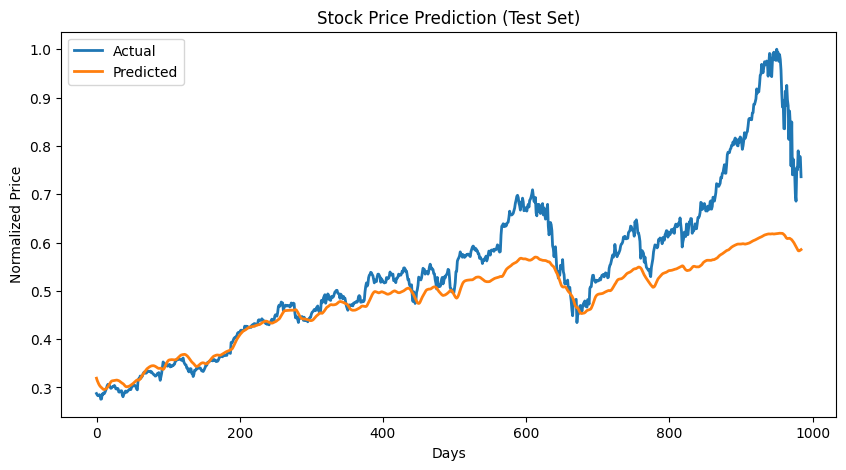

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_true, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)
plt.title("Stock Price Prediction (Test Set)")
plt.xlabel("Days")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()


In [16]:
torch.save(model.state_dict(), "lstm_stock_model.pth")
import joblib
joblib.dump(scaler, "scaler.save")

print("Model and scaler saved successfully!")


Model and scaler saved successfully!
